# Lesson 2: Drawing maps and timelines to understand spatial and temporal coverages 👀

### 🎯 Learning Objectives
In this lesson, we will use the filtered Argo index file (created in Lesson 1) to visualize and understand the trajectories of the floats and their timelines. Doing so will help us identify the floats and profiles we want.

### 🛠️ Prerequisites
Before starting this lesson, make sure that you have completed **Lesson 1**.

### ❓ How to Use This Notebook
* 📚 **Read** the tutorial text blocks carefully, as they provide the essential background information behind the code.
* ▶️ **Run** each code cell sequentially by clicking the cell and pressing `Shift + Enter`.
* 📝 **Exercise** your knowledge! At the end of this notebook, we provide active learning exercises where you will need to write or modify the code yourself.

### Ready? Let's Get Started!
---

## 📚 Tutorial

### Import libraries
▶️ **Run** the cell below to import relevant Python libraries. **NOTE** we import the useful functions created in Lesson 1.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cft 
from datetime import datetime, timedelta
from ipynb.fs.defs.lesson_1 import load_index, filter_index, calculate_float_speed, filter2_and_save_index

### Load the filtered index file

▶️ **Run** the cell below to load the filtered index file created in Lesson 1.

In [2]:
df_index = pd.read_csv('argo_synthetic-profile_index_default.csv',parse_dates=['datetime'])
df_index

,file,latitude,longitude,parameters,datetime,wmo
0,aoml/5906513/profiles/SD5906513_025.nc,27.139,139.571,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-04 17:23:25,5906513
1,aoml/5906513/profiles/SD5906513_026.nc,27.193,139.748,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-15 02:00:45,5906513
2,aoml/5906513/profiles/SD5906513_027.nc,27.255,139.714,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-25 06:42:36,5906513
3,aoml/5906513/profiles/SD5906513_028.nc,27.081,140.029,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-04 11:05:10,5906513
4,aoml/5906513/profiles/SD5906513_029.nc,26.829,139.993,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-14 15:13:24,5906513
...,...,...,...,...,...,...
313,csio/2902882/profiles/SR2902882_174.nc,20.532,139.938,PRES TEMP PSAL DOXY CHLA BBP532 BBP700 DOWN_IR...,2024-12-11 02:17:22,2902882
314,csio/2902882/profiles/SR2902882_175.nc,20.622,139.968,PRES TEMP PSAL DOXY CHLA BBP532 BBP700 DOWN_IR...,2024-12-16 02:11:21,2902882
315,csio/2902882/profiles/SR2902882_176.nc,20.718,139.975,PRES TEMP PSAL DOXY CHLA BBP532 BBP700 DOWN_IR...,2024-12-21 02:20:16,2902882
316,csio/2902882/profiles/SR2902882_177.nc,20.786,139.957,PRES TEMP PSAL DOXY CHLA BBP532 BBP700 DOWN_IR...,2024-12-26 02:08:23,2902882


### Define a function for drawing maps and timelines

▶️ **Run** the cell below to define a function that draws and saves a map showing the floats' trajectories and the corresponding timeline.

In [3]:
def save_map_timeline(df_index, note = 'default', mapsize = (10,10), timelinesize = (10,10)):
    """
    This function creates a map and timeline and save them as PNG files.
    
    INPUT:
    * df_index: the filtered index file generated by `filter2_and_save` (format: pandas dataframe)
    * note (optional): suffix for the file names (format: string)
    * mapsize (optional): figure size for the map (format: (width, height))
    * timelinesize (optional): figure size for the timeline (format: (width, height))
    
    OUTPUT:
    * map_{note}.png
    * timeline_{note}.png
    """

    plt.close('all')
    
    # Pre-sort the entire DataFrame once, rather than inside the loop
    df_index = df_index.sort_values(['wmo', 'datetime'])
    
    # Save the projection to a short variable to avoid typing it 4 times
    crs = ccrs.PlateCarree()
    
    # --- 1. Map Setup (fig1) ---
    # plt.subplots() creates both the figure and axes in one clean line
    fig1, ax1 = plt.subplots(figsize=mapsize, subplot_kw={'projection': crs})
    ax1.add_feature(cft.LAND)
    
    # Adding a small buffer (0.1 degrees) so dots don't touch the exact edge of the map
    pad = 0.1
    ax1.set_extent([df_index['longitude'].min() - pad, df_index['longitude'].max() + pad,
                    df_index['latitude'].min() - pad, df_index['latitude'].max() + pad], crs=crs)
    
    gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color="None")
    gl.top_labels = False
    gl.right_labels = False
    
    # --- 2. Timeline Setup (fig2) ---
    fig2, ax2 = plt.subplots(figsize=timelinesize)
    cmap_colors = plt.colormaps['tab10'].colors
    wmo_list = [] # We will build this list automatically in the loop!
    
    # --- 3. The Plotting Loop ---
    # .groupby() automatically splits the DataFrame by WMO without needing to manually filter!
    for i, (wmo, group) in enumerate(df_index.groupby('wmo')):
        
        color = cmap_colors[i % len(cmap_colors)]
        wmo_list.append(wmo) # Save the WMO for the y-axis labels later
        
        # Plot Map (ax1)
        ax1.scatter(group['longitude'], group['latitude'], color=color, transform=crs, zorder=3, s=0.1)
        
        # Grab the last coordinate once to keep the next lines clean
        last_lon = group['longitude'].iloc[-1]
        last_lat = group['latitude'].iloc[-1]
        
        ax1.scatter(last_lon, last_lat, color='k', marker='.', transform=crs, zorder=4, s=6)
        ax1.text(last_lon, last_lat, str(i+1), color='k', transform=crs, zorder=5, fontsize=5)
        
        # Plot Time Series (ax2)
        ax2.scatter(group['datetime'], [i]*len(group), color=color, marker='|', linewidths=0.5)
    
    # --- 4. Final Formatting & Saving ---
    fig1.tight_layout()
    fig1.savefig(f'map_{note}.png', dpi=300, bbox_inches='tight')
    
    ax2.set_yticks(range(len(wmo_list)))
    formatted_labels = [f"{wmo} ({i+1})" for i, wmo in enumerate(wmo_list)]
    ax2.set_yticklabels(formatted_labels)
    ax2.set_xlim(df_index['datetime'].min(), df_index['datetime'].max())
    ax2.set_ylabel('WMO (label on the map)')
    fig2.tight_layout()
    fig2.savefig(f'timeline_{note}.png', dpi=300, bbox_inches='tight')

### Draw the map and timeline 

▶️ **Run** the cell below to use the function `save_map_timeline`.

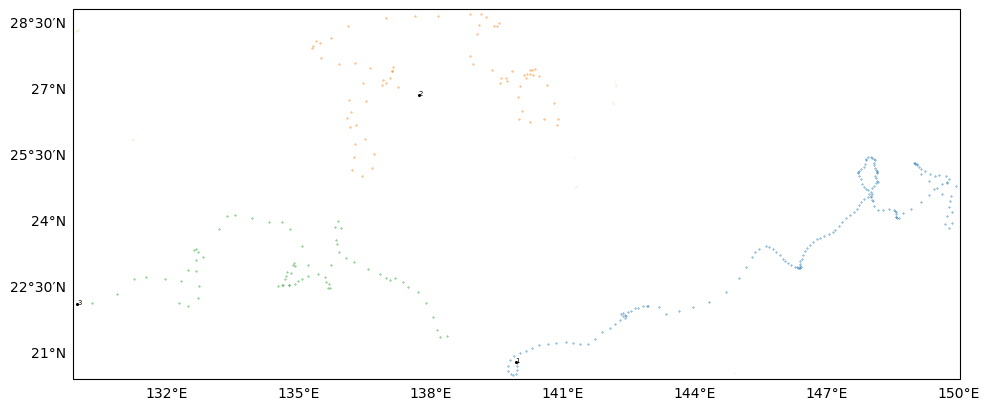

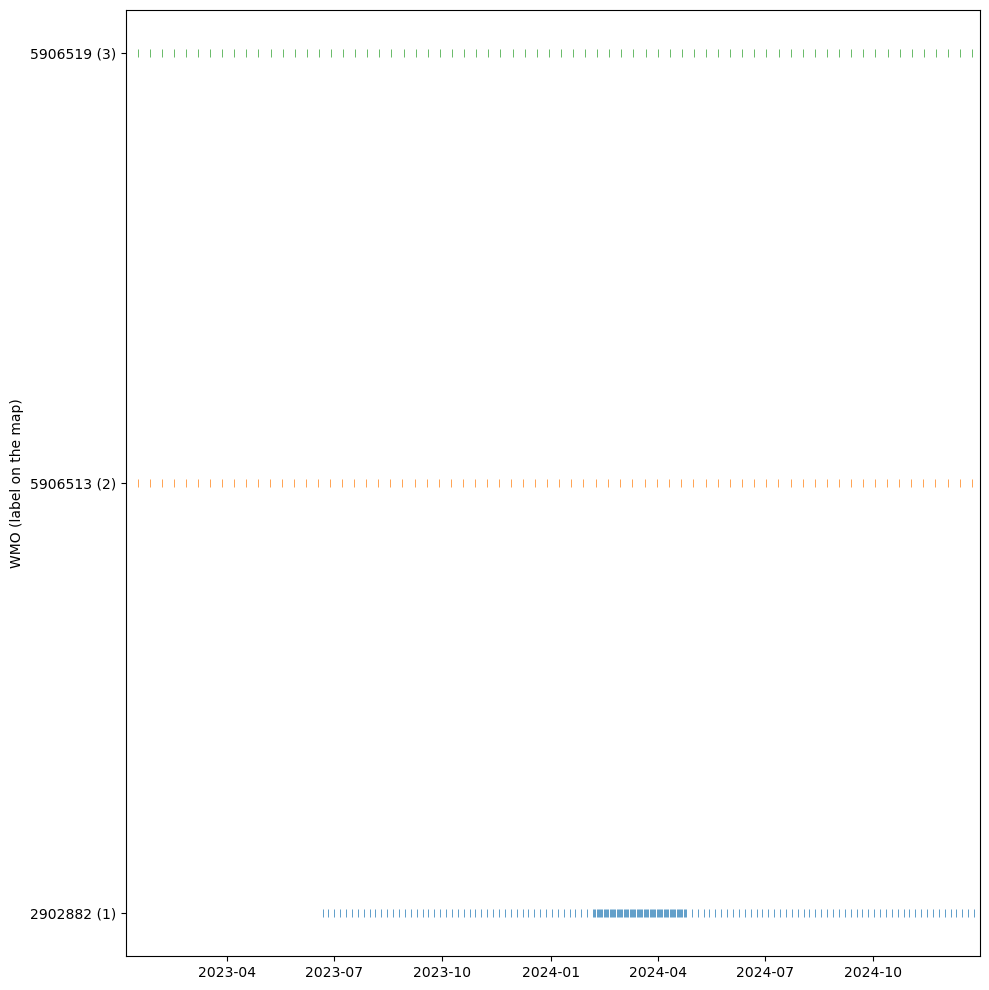

In [4]:
save_map_timeline(df_index)

**This is the end of the tutorials for Lesson 2. Hope you enjoyed it!**


---

## 📝 Exercises

Using the filtered index files created in Lesson 1 with the three different use cases, create the corresponding maps and timelines using the function `save_map_timeline` (**TIP**: Provide the optional argument `note` so that the function will not overwrite the figures created above).

### Exercise 1: Chlorophyll-a measurements in the global ocean on March 1, 2026

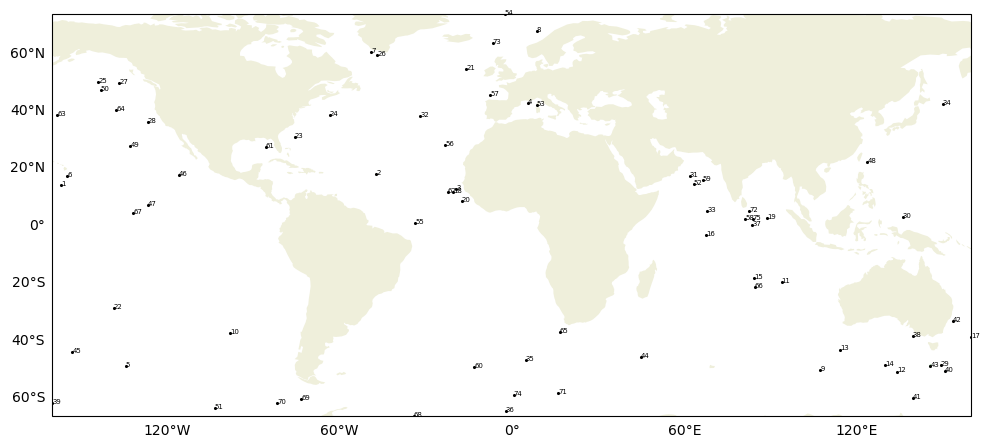

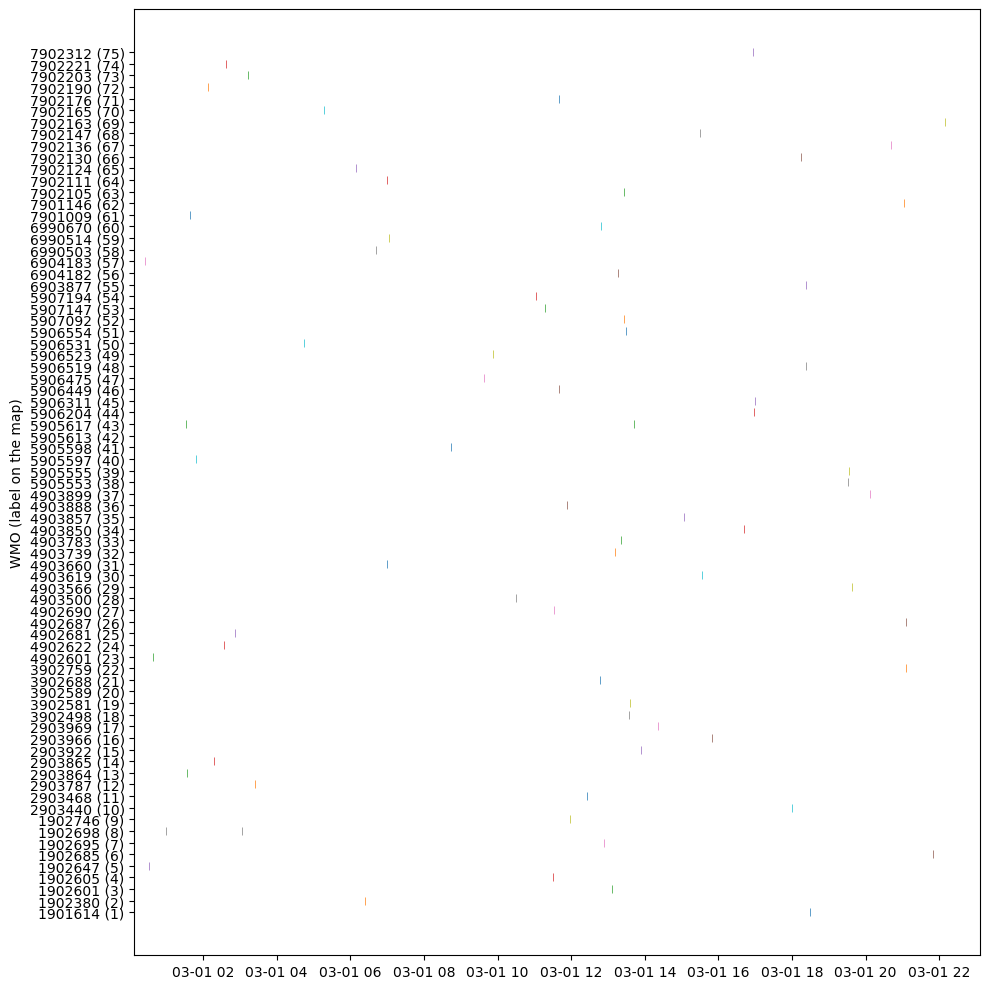

In [5]:
df_index = pd.read_csv('argo_synthetic-profile_index_ex1.csv',parse_dates=['datetime'])
note = 'ex1'
save_map_timeline(df_index, note)

### Exercise 2: *Full-sensor* BGC-Argo floats in the Indian Ocean at least once per month and at least for a year between 2018 and 2025

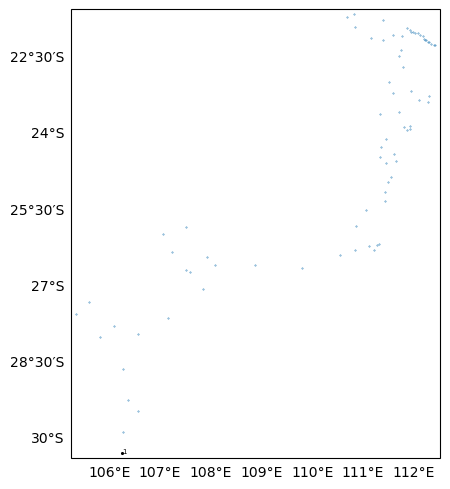

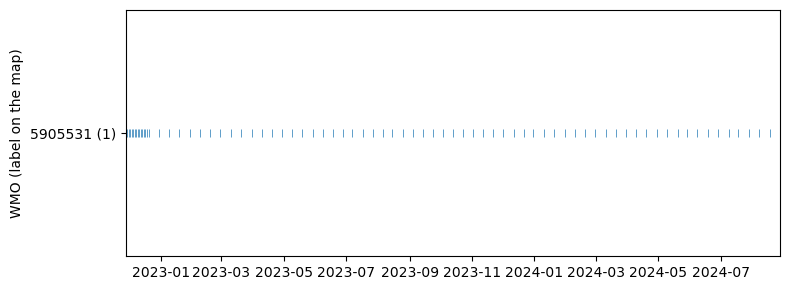

In [6]:
df_index = pd.read_csv('argo_synthetic-profile_index_ex2.csv',parse_dates=['datetime'])
note = 'ex2'
save_map_timeline(df_index, note, mapsize=(5,5), timelinesize=(8,3))

### Exercise 3: Floats that measured both dissolved oxygen and nitrate and drifted at a speed of nore more than 0.05 m/s in the North Pacific between 2019 and 2022

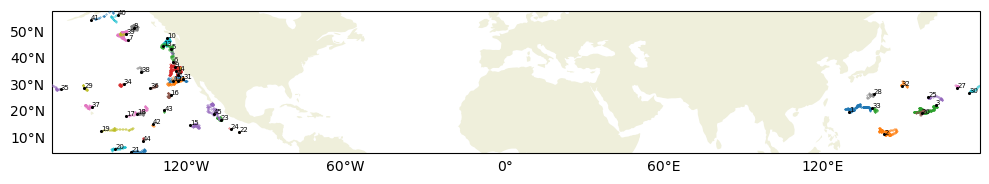

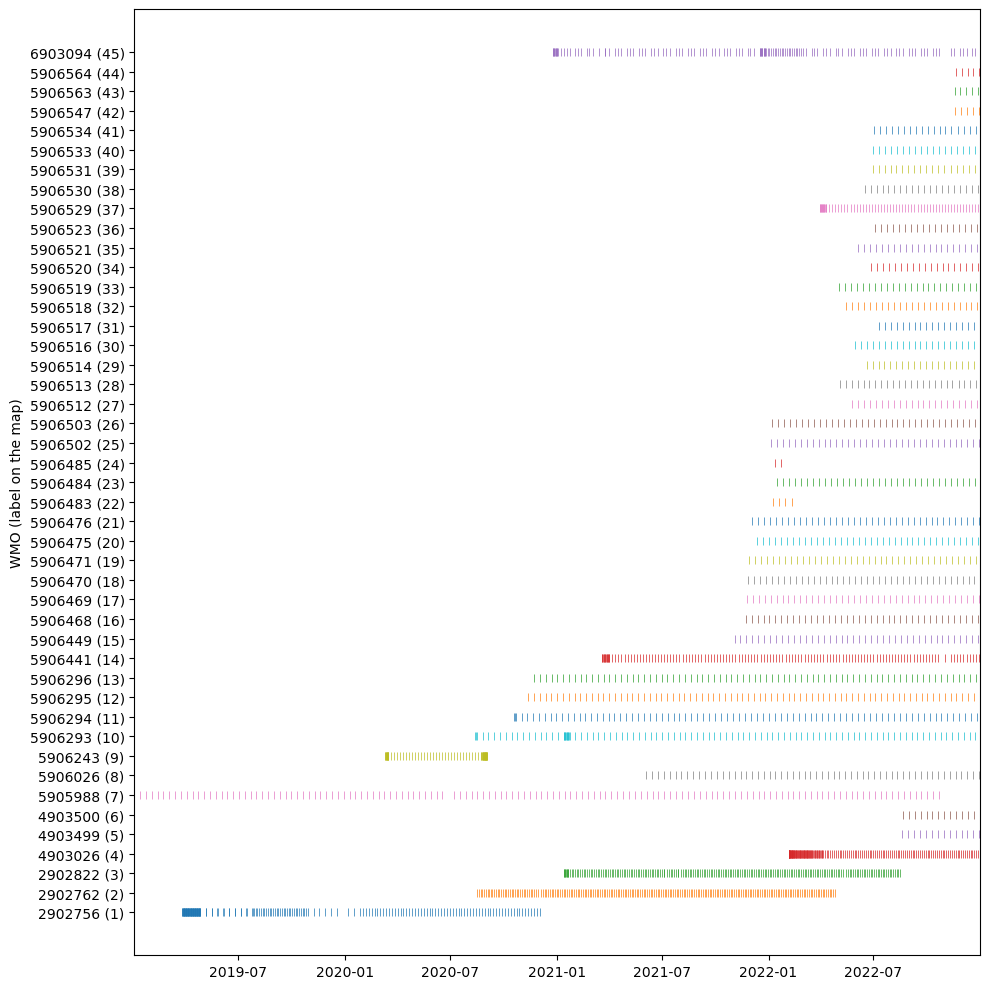

In [10]:
df_index = pd.read_csv('argo_synthetic-profile_index_ex3.csv',parse_dates=['datetime'])
note = 'ex3'
save_map_timeline(df_index, note)


---

This is the end of the lesson. If you are using **Binder**, don't forget to dowload the files created in this lesson before you lose connection!

Well done 🎉 Take a break 💤, have another cup ☕, and move to the next lesson ✍️ when you are ready 💪

While your memory is fresh, please feel free to provide your user experience on this lesson by visiting [this link](https://forms.gle/oAGmz5RTW4Pp46bt7). Thanks!